In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sqlalchemy import create_engine, text
import warnings
import os
import pathlib
warnings.filterwarnings('ignore')

BASE_DIR = pathlib.Path(os.getcwd())
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

DB_PATH = BASE_DIR / 'data' / 'banco.db'
engine  = create_engine(f'sqlite:///{DB_PATH}', echo=False)

df_c   = pd.read_sql('SELECT * FROM tb_clientes', engine)
df_c   = df_c.drop(columns=['cluster_id','cluster_nome'], errors='ignore')
df_cl  = pd.read_sql('SELECT id_cliente, cluster_id, cluster_nome FROM tb_clusters', engine)
df_rfm = pd.read_sql('SELECT * FROM tb_rfm', engine)

df = df_c.merge(df_cl, on='id_cliente', how='left')
df = df.merge(df_rfm, on='id_cliente', how='left')

print(f"Clientes: {len(df):,} | Colunas: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"cluster_nome únicos: {df['cluster_nome'].unique()}")

Clientes: 300,000 | Colunas: 52
Missing values: 0
cluster_nome únicos: <ArrowStringArray>
['Trajetória Crescente',     'Potencial Oculto',     'Primeiros Passos',
            'Self Made',            'Old Money']
Length: 5, dtype: str


In [6]:
# Verifica se o banco está no lugar certo
print(f"Banco: {DB_PATH}")
print(f"Banco existe: {DB_PATH.exists()}")

with engine.connect() as conn:
    tabelas = [row[0] for row in conn.execute(text("SELECT name FROM sqlite_master WHERE type='table'"))]
    print(f"Tabelas existentes: {tabelas}")

Banco: c:\Users\caleb\Documents\SANTANDER-MOTOR-RECOMENDACAO\data\banco.db
Banco existe: True
Tabelas existentes: ['tb_ibge_salarios', 'tb_estados_cidades', 'tb_clientes', 'tb_clusters', 'tb_perfil_clusters', 'tb_rfm', 'tb_depara', 'tb_depara_clientes']


In [7]:
FEATURES_PROPENSAO = [
    'idade', 'renda_mensal', 'salario_referencia', 'score_credito',
    'saldo_medio', 'media_transacoes_mes', 'uso_app_dias_mes',
    'meses_relacionamento', 'teve_inadimplencia_12m', 'qtd_produtos',
    'rfm_score', 'rfm_recencia', 'rfm_frequencia', 'rfm_monetario',
    'cluster_id',
]

PRODUTOS_ALVO = [
    'tem_investimento',
    'tem_previdencia',
    'tem_credito_imobiliario',
    'tem_cartao_credito',
    'tem_seguro',
    'tem_cambio',
]

print("Features:")
for f in FEATURES_PROPENSAO:
    status = '✓' if f in df.columns else '✗ FALTANDO'
    print(f"  {status} {f}")

print(f"\nProdutos alvo: {PRODUTOS_ALVO}")

Features:
  ✓ idade
  ✓ renda_mensal
  ✓ salario_referencia
  ✓ score_credito
  ✓ saldo_medio
  ✓ media_transacoes_mes
  ✓ uso_app_dias_mes
  ✓ meses_relacionamento
  ✓ teve_inadimplencia_12m
  ✓ qtd_produtos
  ✓ rfm_score
  ✓ rfm_recencia
  ✓ rfm_frequencia
  ✓ rfm_monetario
  ✓ cluster_id

Produtos alvo: ['tem_investimento', 'tem_previdencia', 'tem_credito_imobiliario', 'tem_cartao_credito', 'tem_seguro', 'tem_cambio']


In [8]:
modelos_propensao = {}
resultados        = []

print("Treinando modelos de propensão...\n")

for produto in PRODUTOS_ALVO:
    X = df[FEATURES_PROPENSAO]
    y = df[produto]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train_sc, y_train)

    auc = roc_auc_score(y_test, modelo.predict_proba(X_test_sc)[:,1])

    modelos_propensao[produto] = {'modelo': modelo, 'scaler': scaler, 'auc': auc}

    resultados.append({
        'produto':   produto.replace('tem_','').replace('_',' ').title(),
        'auc_roc':   auc,
        'taxa_base': y.mean(),
    })

    print(f"{produto.replace('tem_','').title():25} AUC-ROC: {auc:.4f} | Taxa base: {y.mean():.1%}")

df_resultados = pd.DataFrame(resultados).sort_values('auc_roc', ascending=False)
print(f"\nAUC-ROC médio: {df_resultados['auc_roc'].mean():.4f}")

Treinando modelos de propensão...

Investimento              AUC-ROC: 0.8085 | Taxa base: 46.4%
Previdencia               AUC-ROC: 0.8018 | Taxa base: 35.9%
Credito_Imobiliario       AUC-ROC: 0.8104 | Taxa base: 24.4%
Cartao_Credito            AUC-ROC: 0.7944 | Taxa base: 82.2%
Seguro                    AUC-ROC: 0.7597 | Taxa base: 42.8%
Cambio                    AUC-ROC: 0.8424 | Taxa base: 20.3%

AUC-ROC médio: 0.8029


In [9]:
print("Calculando scores de propensão...")

for produto, info in modelos_propensao.items():
    X_scaled  = info['scaler'].transform(df[FEATURES_PROPENSAO])
    col_score = f"propensao_{produto.replace('tem_','')}"
    df[col_score] = (info['modelo'].predict_proba(X_scaled)[:,1] * 100).round(1)

cols_propensao = [c for c in df.columns if c.startswith('propensao_')]

print(f"Scores gerados: {len(cols_propensao)} produtos")
print(f"Colunas: {cols_propensao}")
print(f"\nMédia por produto:")
print(df[cols_propensao].mean().round(1).sort_values(ascending=False))
print(f"\ncluster_nome únicos: {df['cluster_nome'].unique()}")
print(f"Propensão no df: {cols_propensao}")

Calculando scores de propensão...
Scores gerados: 6 produtos
Colunas: ['propensao_investimento', 'propensao_previdencia', 'propensao_credito_imobiliario', 'propensao_cartao_credito', 'propensao_seguro', 'propensao_cambio']

Média por produto:
propensao_cartao_credito         82.2
propensao_investimento           46.3
propensao_seguro                 42.8
propensao_previdencia            35.9
propensao_credito_imobiliario    24.4
propensao_cambio                 20.3
dtype: float64

cluster_nome únicos: <ArrowStringArray>
['Trajetória Crescente',     'Potencial Oculto',     'Primeiros Passos',
            'Self Made',            'Old Money']
Length: 5, dtype: str
Propensão no df: ['propensao_investimento', 'propensao_previdencia', 'propensao_credito_imobiliario', 'propensao_cartao_credito', 'propensao_seguro', 'propensao_cambio']


propensao_cluster shape: (5, 6)
                      Investimento  Previdencia  Credito Imobiliario  \
cluster_nome                                                           
Old Money                94.202625    88.448335            68.300040   
Potencial Oculto         42.698564    30.562070            18.274526   
Primeiros Passos         10.663209     7.427656             4.022808   
Self Made                76.638496    61.110860            46.945556   
Trajetória Crescente     32.783633    24.462960            14.506931   

                      Cartao Credito     Seguro     Cambio  
cluster_nome                                                
Old Money                  98.814860  78.479803  77.796841  
Potencial Oculto           83.422315  41.228471  13.105061  
Primeiros Passos           48.991031  15.054672   1.785784  
Self Made                  95.758158  58.122532  43.239367  
Trajetória Crescente       78.912963  36.791304   8.598909  


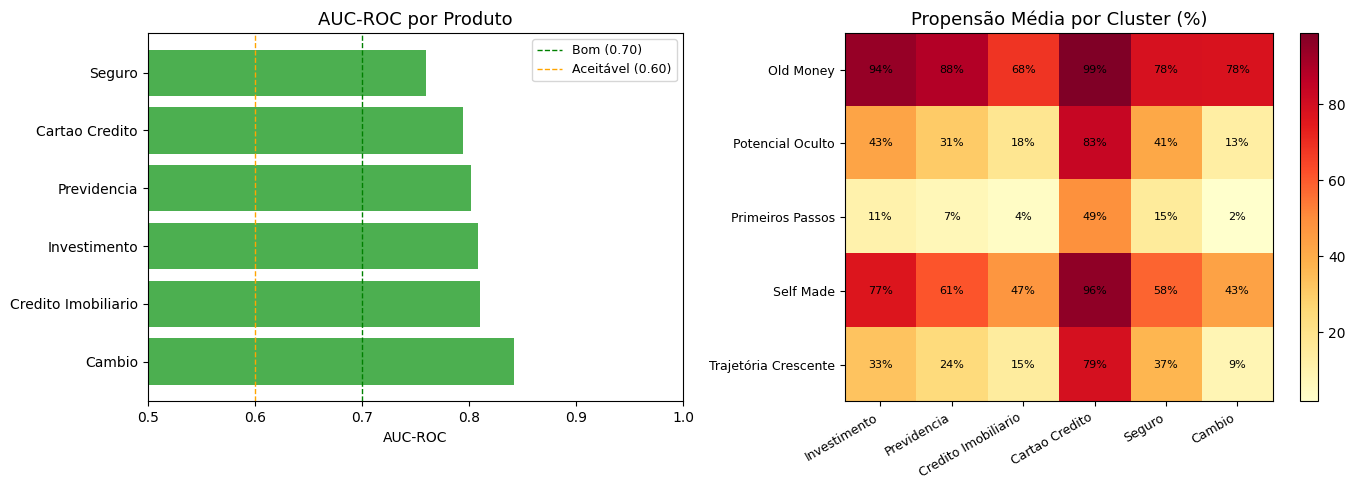

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — AUC-ROC
cores_auc = ['#4CAF50' if x>=0.70 else '#FF9800' if x>=0.60 else '#FF5722'
             for x in df_resultados['auc_roc']]
axes[0].barh(df_resultados['produto'], df_resultados['auc_roc'], color=cores_auc)
axes[0].axvline(x=0.70, color='green', linestyle='--', linewidth=1, label='Bom (0.70)')
axes[0].axvline(x=0.60, color='orange', linestyle='--', linewidth=1, label='Aceitável (0.60)')
axes[0].set_title('AUC-ROC por Produto', fontsize=13)
axes[0].set_xlabel('AUC-ROC')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0.5, 1.0)

# Gráfico 2 — Heatmap propensão por cluster
propensao_cluster = df.groupby('cluster_nome')[cols_propensao].mean()
propensao_cluster.columns = [
    c.replace('propensao_','').replace('_',' ').title()
    for c in propensao_cluster.columns
]

print(f"propensao_cluster shape: {propensao_cluster.shape}")
print(propensao_cluster)

im = axes[1].imshow(propensao_cluster.values, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(len(propensao_cluster.columns)))
axes[1].set_xticklabels(propensao_cluster.columns, rotation=30, ha='right', fontsize=9)
axes[1].set_yticks(range(len(propensao_cluster.index)))
axes[1].set_yticklabels(propensao_cluster.index, fontsize=9)
axes[1].set_title('Propensão Média por Cluster (%)', fontsize=13)
plt.colorbar(im, ax=axes[1])

for i in range(len(propensao_cluster.index)):
    for j in range(len(propensao_cluster.columns)):
        axes[1].text(j, i, f"{propensao_cluster.values[i,j]:.0f}%",
                    ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'docs' / 'propensao_produtos.png'), dpi=150, bbox_inches='tight')
plt.show()

In [13]:
df_prop = df[['id_cliente'] + cols_propensao].copy()

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS tb_propensao"))
    conn.commit()

df_prop.to_sql('tb_propensao', engine, if_exists='replace', index=False)

print("=== DIAGNÓSTICO FINAL 04 ===")
with engine.connect() as conn:
    total = conn.execute(text("SELECT COUNT(*) FROM tb_propensao")).scalar()
    print(f"tb_propensao: {total:,} registros")

print(f"\nAUC-ROC por produto:")
for _, row in df_resultados.iterrows():
    status = '✓ Bom' if row['auc_roc']>=0.70 else '~ OK' if row['auc_roc']>=0.60 else '✗ Baixo'
    print(f"  {status} | {row['produto']:25} | {row['auc_roc']:.4f}")

print(f"\nTabelas no banco:")
with engine.connect() as conn:
    for row in conn.execute(text("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")):
        count = conn.execute(text(f"SELECT COUNT(*) FROM {row[0]}")).scalar()
        print(f"  {row[0]:25} | {count:,} registros")

=== DIAGNÓSTICO FINAL 04 ===
tb_propensao: 300,000 registros

AUC-ROC por produto:
  ✓ Bom | Cambio                    | 0.8424
  ✓ Bom | Credito Imobiliario       | 0.8104
  ✓ Bom | Investimento              | 0.8085
  ✓ Bom | Previdencia               | 0.8018
  ✓ Bom | Cartao Credito            | 0.7944
  ✓ Bom | Seguro                    | 0.7597

Tabelas no banco:
  tb_clientes               | 300,000 registros
  tb_clusters               | 300,000 registros
  tb_depara                 | 5 registros
  tb_depara_clientes        | 300,000 registros
  tb_estados_cidades        | 64 registros
  tb_ibge_salarios          | 69 registros
  tb_perfil_clusters        | 5 registros
  tb_propensao              | 300,000 registros
  tb_rfm                    | 300,000 registros


In [14]:
# Verifica se tb_propensao foi salva
with engine.connect() as conn:
    total = conn.execute(text("SELECT COUNT(*) FROM tb_propensao")).scalar()
    print(f"tb_propensao: {total:,} registros")
    print(f"Colunas: {cols_propensao}")

tb_propensao: 300,000 registros
Colunas: ['propensao_investimento', 'propensao_previdencia', 'propensao_credito_imobiliario', 'propensao_cartao_credito', 'propensao_seguro', 'propensao_cambio']
